# 1.Loading Libraries

In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay,mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2.Importing Data Set

In [26]:
df = pd.read_csv('/home/ali/AI/diabetes-health-indicators-ml/data/raw/diabetes_dataset.csv', delimiter=',')

# 3.Checking data And Inspections

In [27]:
print(df.head())

   age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   48  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
0                                 215         5.7  ...               41   
1                                 143         6.7  ...               55   
2                

In [28]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [29]:
print(df.dtypes)

age                                     int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
employment_status                      object
smoking_status                         object
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

In [30]:
df.shape

(100000, 31)

In [31]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [32]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [33]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts)

has_nulls = df.isnull().any().any()
print(f"\nAre there any null values in the dataset? {has_nulls}")

Null values per column:
age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting 

In [34]:
df.dtypes

age                                     int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
employment_status                      object
smoking_status                         object
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

# 4.Pre Processing Data

### a.Categorical columns to encode

In [35]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')


### b.Label encode each

In [36]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### c.Encode multiclass target

In [37]:
df['diabetes_stage_encoded'] = le.fit_transform(df['diabetes_stage'])

### c.Define features (drop all 3 targets from features)

In [38]:
X = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage','diabetes_risk_score', 'diabetes_stage_encoded'])

### d.Scale features

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### e.Save processed data

In [40]:
pd.DataFrame(X_scaled, columns=X.columns).to_csv('/home/ali/AI/diabetes-health-indicators-ml/data/processed/X_scaled.csv', index=False)
df.to_csv('/home/ali/AI/diabetes-health-indicators-ml/data/processed/df_encoded.csv', index=False)

# 5.Exploratory Data Analysis

### a.Target distribution - Binary

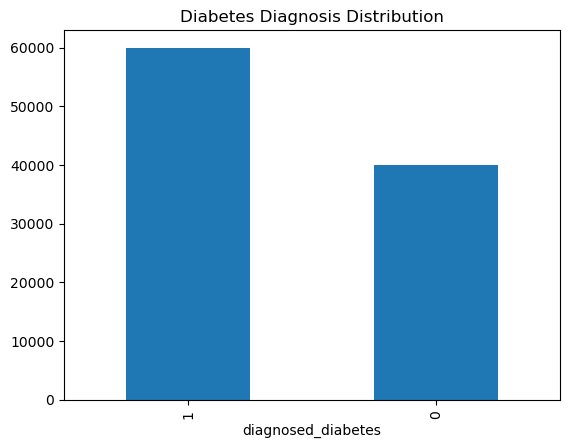

In [41]:
df['diagnosed_diabetes'].value_counts().plot(kind='bar')
plt.title('Diabetes Diagnosis Distribution')
plt.show()

### b.Target distribution - Multiclass

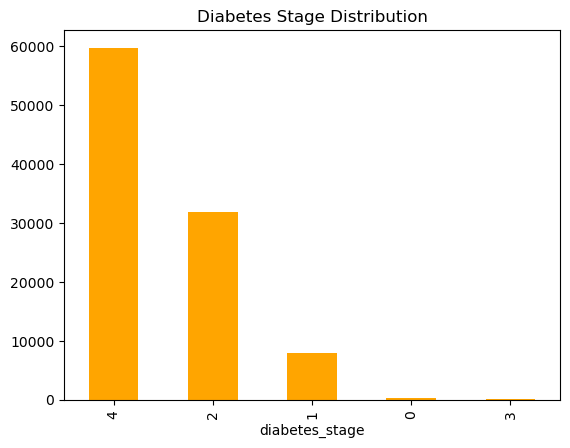

In [42]:
df['diabetes_stage'].value_counts().plot(kind='bar', color='orange')
plt.title('Diabetes Stage Distribution')
plt.show()


### c.Correlation heatmap (numerical only)

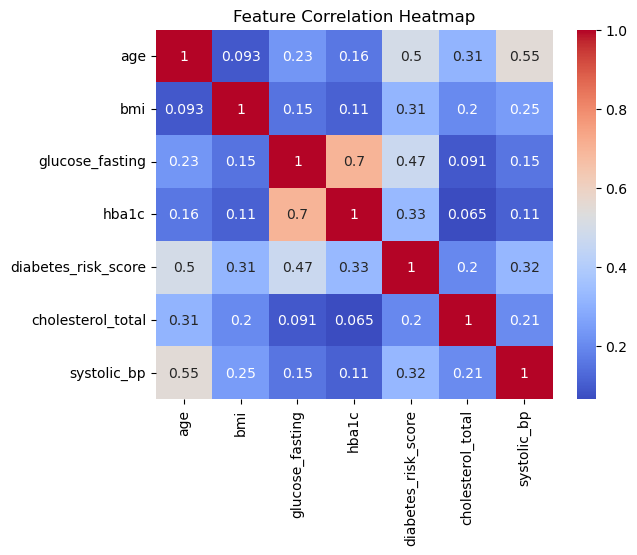

In [43]:
num_cols = ['age', 'bmi', 'glucose_fasting', 'hba1c','diabetes_risk_score', 'cholesterol_total', 'systolic_bp']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### d.BMI vs Risk Score


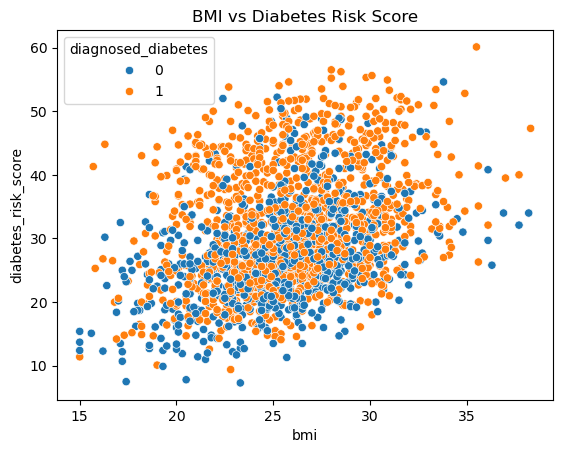

In [44]:
sns.scatterplot(x='bmi', y='diabetes_risk_score',hue='diagnosed_diabetes', data=df.sample(2000))
plt.title('BMI vs Diabetes Risk Score')
plt.show()

### e.Boxplots - glucose by stage


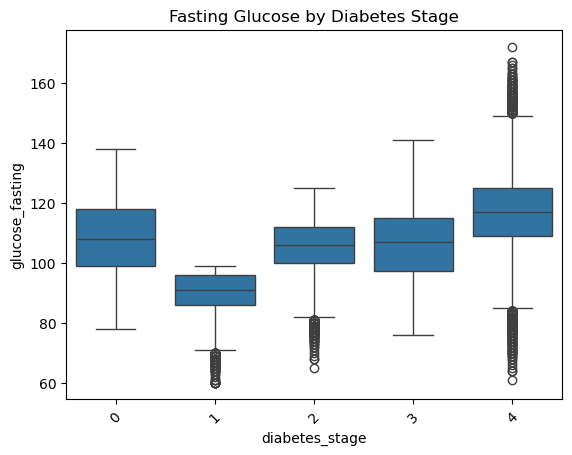

In [45]:
sns.boxplot(x='diabetes_stage', y='glucose_fasting', data=df)
plt.xticks(rotation=45)
plt.title('Fasting Glucose by Diabetes Stage')
plt.show()

# 6.Data Splitting

### a.Binary Classification

In [46]:
X_bin = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage','diabetes_risk_score', 'diabetes_stage_encoded'])
y_bin = df['diagnosed_diabetes']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, stratify=y_bin, random_state=42)

### b.Multi Class Classification

In [47]:
y_multi = df['diabetes_stage_encoded']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_bin, y_multi, test_size=0.2, stratify=y_multi, random_state=42)

### c.Regression

In [48]:
y_reg = df['diabetes_risk_score']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_bin, y_reg, test_size=0.2, random_state=42)

# 7.Baseline Model Training & Evaluation

### a.Binary Classification

/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      8000
           1       0.85      0.88      0.86     12000

    accuracy                           0.83     20000
   macro avg       0.83      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000

ROC-AUC: 0.9098545937500001


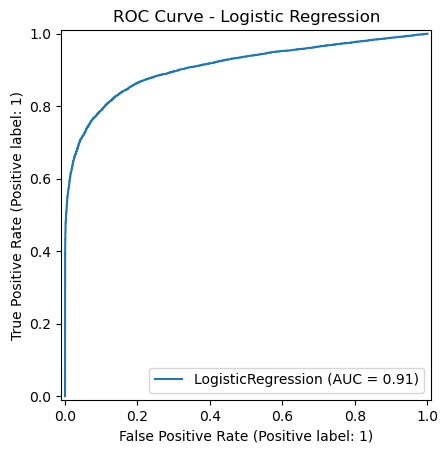


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.86     20000
weighted avg       0.86      0.86      0.86     20000

ROC-AUC: 0.8539791666666667


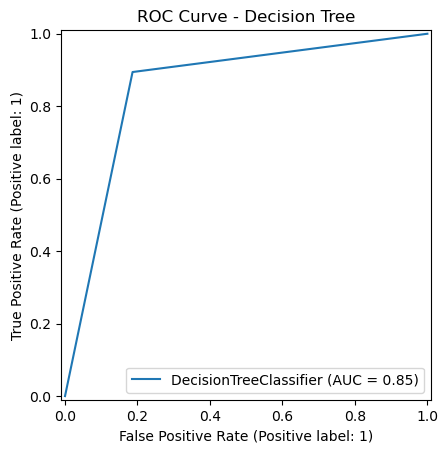


=== KNN ===
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      8000
           1       0.85      0.82      0.84     12000

    accuracy                           0.81     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.81      0.81      0.81     20000

ROC-AUC: 0.8719847604166667


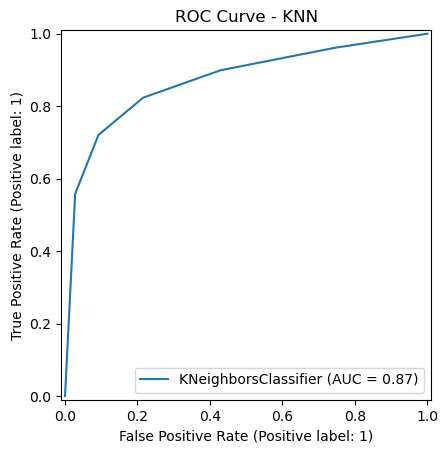

In [49]:
models_bin = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier()
}

for name, model in models_bin.items():
    model.fit(X_train_b, y_train_b)
    y_pred = model.predict(X_test_b)
    print(f"\n=== {name} ===")
    print(classification_report(y_test_b, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test_b, model.predict_proba(X_test_b)[:,1]))
    RocCurveDisplay.from_estimator(model, X_test_b, y_test_b)
    plt.title(f'ROC Curve - {name}')
    plt.show()

### b.Multiclass Classification


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.03      0.04      0.03        56
           1       0.85      0.82      0.84      1596
           2       0.84      0.80      0.82      6369
           3       0.00      0.00      0.00        24
           4       0.87      0.89      0.88     11955

    accuracy                           0.86     20000
   macro avg       0.52      0.51      0.51     20000
weighted avg       0.86      0.86      0.86     20000



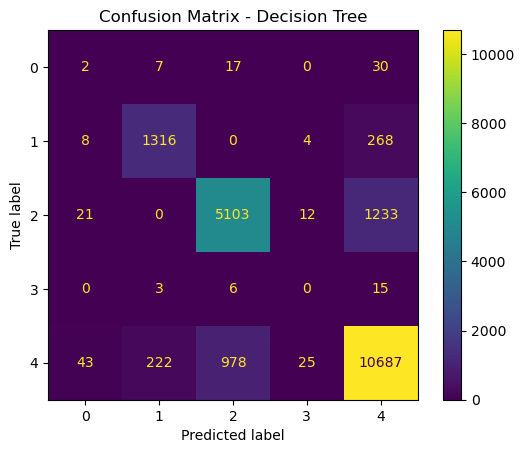


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.68      0.52      0.59      1596
           2       0.66      0.62      0.64      6369
           3       0.00      0.00      0.00        24
           4       0.82      0.88      0.85     11955

    accuracy                           0.77     20000
   macro avg       0.43      0.40      0.42     20000
weighted avg       0.76      0.77      0.76     20000



/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ali/miniconda3/envs/data_scien

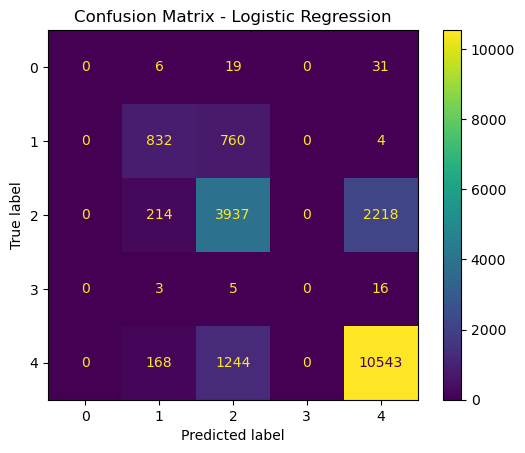


=== KNN ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.61      0.62      0.61      1596
           2       0.64      0.68      0.66      6369
           3       0.00      0.00      0.00        24
           4       0.85      0.82      0.84     11955

    accuracy                           0.76     20000
   macro avg       0.42      0.43      0.42     20000
weighted avg       0.76      0.76      0.76     20000



/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ali/miniconda3/envs/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

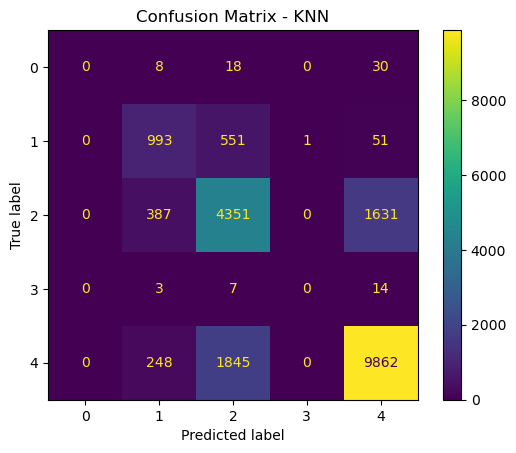

In [50]:
models_multi = {
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier()
}

for name, model in models_multi.items():
    model.fit(X_train_m, y_train_m)
    y_pred = model.predict(X_test_m)
    print(f"\n=== {name} ===")
    print(classification_report(y_test_m, y_pred))
    cm = confusion_matrix(y_test_m, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

### c.Regression

In [51]:
models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor()
}

for name, model in models_reg.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    print(f"\n=== {name} ===")
    print("MAE:", mean_absolute_error(y_test_r, y_pred))
    print("MSE:", mean_squared_error(y_test_r, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred)))
    print("R²:", r2_score(y_test_r, y_pred))


=== Linear Regression ===
MAE: 0.4390348175160103
MSE: 0.5543951317087538
RMSE: 0.7445771496015398
R²: 0.9932822841351281

=== Decision Tree Regressor ===
MAE: 1.2462849999999999
MSE: 2.5363985000000002
RMSE: 1.5926074532037078
R²: 0.9692659558705533
